# Exercise 1:

In [1]:
import pandas as pd
import numpy as np

# Load datasets
customers_df = pd.read_csv('content/customer_data.csv')
transactions_df = pd.read_csv('content/transaction_data.csv')

print("Customers Dataset:")
print(customers_df)
print("\nTransactions Dataset:")
print(transactions_df)

Customers Dataset:
   CustomerID          Name   Age             Email     Region
0           1   Arjun Kumar  25.0   arjun@email.com      Delhi
1           2  Priya Sharma  30.0   priya@email.com  Bangalore
2           3  Rajesh Patel   NaN  rajesh@email.com     Mumbai
3           4  Anjali Singh  45.0  anjali@email.com      Delhi
4           5  Deepak Verma  35.0  deepak@email.com        NaN
5           6  Kavita Reddy  28.0  kavita@email.com    Chennai
6           7   Rahul Gupta  50.0   rahul@email.com  Bangalore
7           8   Meena Desai   NaN   meena@email.com     Mumbai
8           9  Harish Mehta  42.0  harish@email.com      Delhi
9          10   Indira Nair  33.0  indira@email.com    Chennai

Transactions Dataset:
    TransactionID  CustomerID     Product  Quantity  Price
0               1           1      Laptop         1   1000
1               2           2       Phone         2    800
2               3           2      Tablet         1    500
3               4           3

In [2]:
# Merge datasets with outer join
merged_df = pd.merge(customers_df, transactions_df, on='CustomerID', how='outer')
print("Merged Dataset:")
print(merged_df)

Merged Dataset:
    CustomerID          Name   Age             Email     Region  \
0            1   Arjun Kumar  25.0   arjun@email.com      Delhi   
1            1   Arjun Kumar  25.0   arjun@email.com      Delhi   
2            2  Priya Sharma  30.0   priya@email.com  Bangalore   
3            2  Priya Sharma  30.0   priya@email.com  Bangalore   
4            3  Rajesh Patel   NaN  rajesh@email.com     Mumbai   
5            4  Anjali Singh  45.0  anjali@email.com      Delhi   
6            5  Deepak Verma  35.0  deepak@email.com        NaN   
7            6  Kavita Reddy  28.0  kavita@email.com    Chennai   
8            7   Rahul Gupta  50.0   rahul@email.com  Bangalore   
9            8   Meena Desai   NaN   meena@email.com     Mumbai   
10           9  Harish Mehta  42.0  harish@email.com      Delhi   
11           9  Harish Mehta  42.0  harish@email.com      Delhi   
12           9  Harish Mehta  42.0  harish@email.com      Delhi   
13          10   Indira Nair  33.0  indira@ema

In [3]:
# Standardize regions
region_mapping = {
    'Bangalore': 'Bengaluru',
    'Mumbai': 'Mumbai',
    'Delhi': 'Delhi',
    'Chennai': 'Chennai'
}

merged_df['Region'] = merged_df['Region'].map(region_mapping)
print("Unique Regions after standardization:")
print(merged_df['Region'].unique())

Unique Regions after standardization:
['Delhi' 'Bengaluru' 'Mumbai' nan 'Chennai']


In [4]:
# Calculate total amount
merged_df['TotalAmount'] = merged_df['Quantity'] * merged_df['Price']
print("Dataset with TotalAmount:")
print(merged_df[['CustomerID', 'Name', 'Product', 'Quantity', 'Price', 'TotalAmount']])

Dataset with TotalAmount:
    CustomerID          Name     Product  Quantity  Price  TotalAmount
0            1   Arjun Kumar      Laptop         1   1000         1000
1            1   Arjun Kumar     Charger         3     30           90
2            2  Priya Sharma       Phone         2    800         1600
3            2  Priya Sharma      Tablet         1    500          500
4            3  Rajesh Patel     Monitor         3    300          900
5            4  Anjali Singh    Keyboard         2    100          200
6            5  Deepak Verma       Mouse         1     50           50
7            6  Kavita Reddy     Printer         1    200          200
8            7   Rahul Gupta     Scanner         1    150          150
9            8   Meena Desai  Headphones         2     80          160
10           9  Harish Mehta     Speaker         1    120          120
11           9  Harish Mehta      Camera         1    400          400
12           9  Harish Mehta       Watch         1 

In [5]:
# Customer analysis
top_5_by_id = merged_df.groupby('CustomerID')['TotalAmount'].sum().nlargest(5)
print("Top 5 customers by CustomerID with highest spending:")
print(top_5_by_id)

delhi_customers = merged_df[merged_df['Region'] == 'Delhi']
print("\nCustomers from Delhi region:")
print(delhi_customers[['CustomerID', 'Name', 'Region', 'TotalAmount']])

top_5_spenders = merged_df.groupby(['CustomerID', 'Name'])['TotalAmount'].sum().nlargest(5)
print("\nTop 5 customers by total spending:")
print(top_5_spenders)

Top 5 customers by CustomerID with highest spending:
CustomerID
2     2100
1     1090
3      900
9      770
10     260
Name: TotalAmount, dtype: int64

Customers from Delhi region:
    CustomerID          Name Region  TotalAmount
0            1   Arjun Kumar  Delhi         1000
1            1   Arjun Kumar  Delhi           90
5            4  Anjali Singh  Delhi          200
10           9  Harish Mehta  Delhi          120
11           9  Harish Mehta  Delhi          400
12           9  Harish Mehta  Delhi          250

Top 5 customers by total spending:
CustomerID  Name        
2           Priya Sharma    2100
1           Arjun Kumar     1090
3           Rajesh Patel     900
9           Harish Mehta     770
10          Indira Nair      260
Name: TotalAmount, dtype: int64


In [6]:
# Handle missing values
mean_age = merged_df['Age'].mean()
merged_df['Age'] = merged_df['Age'].fillna(mean_age)

mode_region = merged_df['Region'].mode()[0]
merged_df['Region'] = merged_df['Region'].fillna(mode_region)

print("Dataset after handling missing values:")
print(merged_df[['CustomerID', 'Name', 'Age', 'Region']])

Dataset after handling missing values:
    CustomerID          Name        Age     Region
0            1   Arjun Kumar  25.000000      Delhi
1            1   Arjun Kumar  25.000000      Delhi
2            2  Priya Sharma  30.000000  Bengaluru
3            2  Priya Sharma  30.000000  Bengaluru
4            3  Rajesh Patel  35.384615     Mumbai
5            4  Anjali Singh  45.000000      Delhi
6            5  Deepak Verma  35.000000      Delhi
7            6  Kavita Reddy  28.000000    Chennai
8            7   Rahul Gupta  50.000000  Bengaluru
9            8   Meena Desai  35.384615     Mumbai
10           9  Harish Mehta  42.000000      Delhi
11           9  Harish Mehta  42.000000      Delhi
12           9  Harish Mehta  42.000000      Delhi
13          10   Indira Nair  33.000000    Chennai
14          10   Indira Nair  33.000000    Chennai


In [7]:
# Save integrated dataset and analyze customer presence
merged_df.to_csv('content/Integrated_Customers.csv', index=False)

customers_not_in_transactions = customers_df[~customers_df['CustomerID'].isin(transactions_df['CustomerID'])]
print(f"Number of customers not in Transactions dataset: {len(customers_not_in_transactions)}")
print("\nCustomers without transactions:")
print(customers_not_in_transactions)

Number of customers not in Transactions dataset: 0

Customers without transactions:
Empty DataFrame
Columns: [CustomerID, Name, Age, Email, Region]
Index: []


# Exercise 2:

In [8]:
# Load Netflix dataset
netflix_df = pd.read_csv('content/netflix_titles.csv')

print("Shape of the dataset:", netflix_df.shape)
print("\nColumn names and data types:")
print(netflix_df.dtypes)
print("\nFirst 10 records:")
print(netflix_df.head(10))

Shape of the dataset: (6234, 12)

Column names and data types:
show_id          int64
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

First 10 records:
    show_id     type                                    title  \
0  81145628    Movie  Norm of the North: King Sized Adventure   
1  80117401    Movie               Jandino: Whatever it Takes   
2  70234439  TV Show                       Transformers Prime   
3  80058654  TV Show         Transformers: Robots in Disguise   
4  80125979    Movie                             #realityhigh   
5  80163890  TV Show                                  Apaches   
6  70304989    Movie                                 Automata   
7  80164077    Movie       Fabrizio Copano: Solo pienso en mi   
8  80117902  TV Show                       

In [9]:
# Generate summary statistics
print("Summary statistics for numerical columns:")
print(netflix_df.describe())

print("\nMissing values per column:")
print(netflix_df.isnull().sum())

Summary statistics for numerical columns:
            show_id  release_year
count  6.234000e+03    6234.00000
mean   7.670368e+07    2013.35932
std    1.094296e+07       8.81162
min    2.477470e+05    1925.00000
25%    8.003580e+07    2013.00000
50%    8.016337e+07    2016.00000
75%    8.024489e+07    2018.00000
max    8.123573e+07    2020.00000

Missing values per column:
show_id            0
type               0
title              0
director        1969
cast             570
country          476
date_added        11
release_year       0
rating            10
duration           0
listed_in          0
description        0
dtype: int64


In [10]:
# Handle missing values using different methods
df_mean = netflix_df.copy()
df_ffill = netflix_df.copy()
df_drop = netflix_df.copy()

# Method 1: Mean/mode imputation
numeric_columns = df_mean.select_dtypes(include=['int64', 'float64']).columns
categorical_columns = df_mean.select_dtypes(include=['object']).columns

for col in numeric_columns:
    df_mean[col] = df_mean[col].fillna(df_mean[col].mean())
for col in categorical_columns:
    df_mean[col] = df_mean[col].fillna(df_mean[col].mode()[0])

# Method 2: Forward/backward fill
df_ffill = df_ffill.fillna(method='ffill').fillna(method='bfill')

# Method 3: Drop missing values
df_drop = df_drop.dropna()

print("Original dataset shape:", netflix_df.shape)
print("After mean/mode imputation shape:", df_mean.shape)
print("After forward/backward fill shape:", df_ffill.shape)
print("After dropping missing values shape:", df_drop.shape)

print("\nRemaining missing values in each method:")
print("Mean/mode imputation:", df_mean.isnull().sum().sum())
print("Forward/backward fill:", df_ffill.isnull().sum().sum())
print("Dropping:", df_drop.isnull().sum().sum())

Original dataset shape: (6234, 12)
After mean/mode imputation shape: (6234, 12)
After forward/backward fill shape: (6234, 12)
After dropping missing values shape: (3774, 12)

Remaining missing values in each method:
Mean/mode imputation: 0
Forward/backward fill: 0
Dropping: 0


C:\Users\milan\AppData\Local\Temp\ipykernel_20400\2382363911.py:16: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_ffill = df_ffill.fillna(method='ffill').fillna(method='bfill')


In [11]:
# Handle duplicates and standardize values
print("Number of duplicate rows:", netflix_df.duplicated().sum())
netflix_df_clean = netflix_df.drop_duplicates()
print("Shape after removing duplicates:", netflix_df_clean.shape)

# Standardize country names
country_mapping = {
    'United States': 'USA',
    'United States of America': 'USA',
    'UK': 'United Kingdom',
    'Great Britain': 'United Kingdom'
}
netflix_df_clean['country'] = netflix_df_clean['country'].replace(country_mapping)

# Clean text columns
text_columns = ['title', 'description', 'director']
for col in text_columns:
    if col in netflix_df_clean.columns:
        netflix_df_clean[col] = netflix_df_clean[col].str.strip().str.lower()

netflix_df_clean.to_csv('content/dataset_cleaned.csv', index=False)
print("Cleaned dataset saved successfully.")

Number of duplicate rows: 0
Shape after removing duplicates: (6234, 12)
Cleaned dataset saved successfully.


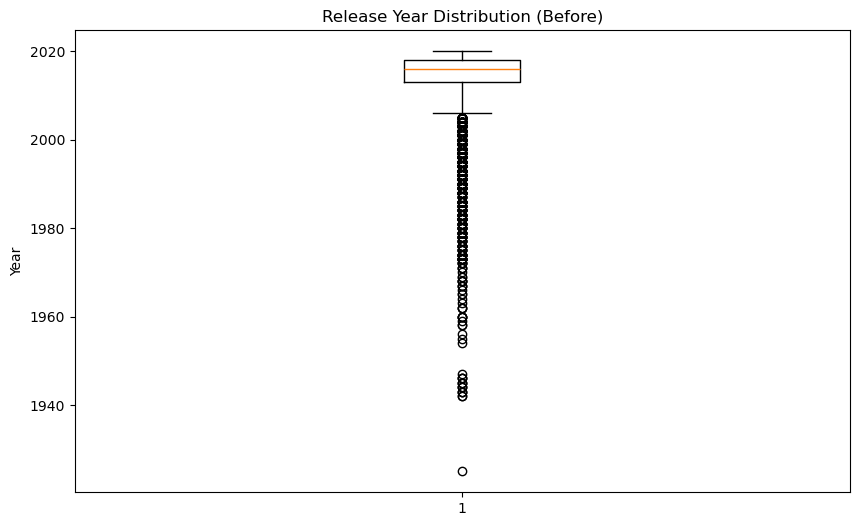

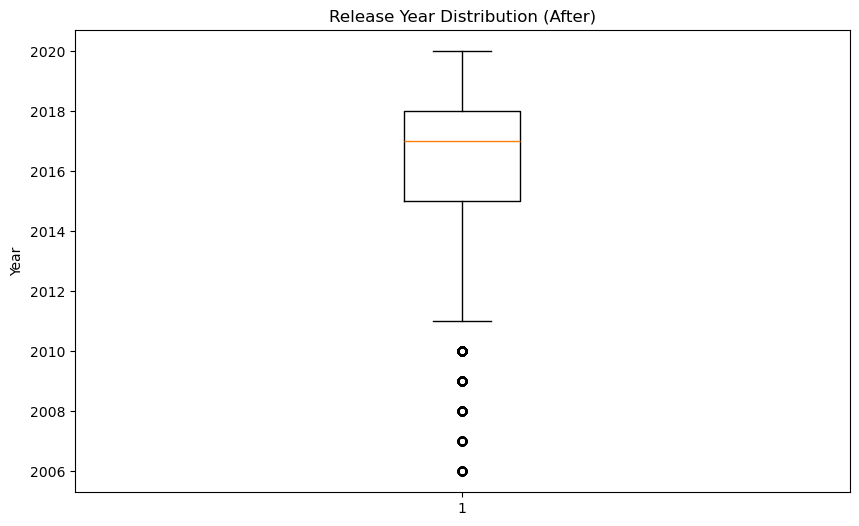

Shape before outlier removal: (6234, 12)
Shape after outlier removal: (5597, 12)
Number of outliers removed: 637


In [12]:
# Outlier detection and removal using IQR method
import matplotlib.pyplot as plt

def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# Visualize before and after outlier removal
plt.figure(figsize=(10, 6))
plt.boxplot(netflix_df_clean['release_year'])
plt.title('Release Year Distribution (Before)')
plt.ylabel('Year')
plt.show()

netflix_df_no_outliers = remove_outliers(netflix_df_clean, 'release_year')

plt.figure(figsize=(10, 6))
plt.boxplot(netflix_df_no_outliers['release_year'])
plt.title('Release Year Distribution (After)')
plt.ylabel('Year')
plt.show()

print(f"Shape before outlier removal: {netflix_df_clean.shape}")
print(f"Shape after outlier removal: {netflix_df_no_outliers.shape}")
print(f"Number of outliers removed: {netflix_df_clean.shape[0] - netflix_df_no_outliers.shape[0]}")

In [13]:
# Create and integrate ratings dataset
sample_size = len(netflix_df_no_outliers)
ratings_data = {
    'title': netflix_df_no_outliers['title'].values,
    'avg_rating': np.random.uniform(1, 5, sample_size).round(2),
    'num_reviews': np.random.randint(10, 1000, sample_size),
    'audience_score': np.random.uniform(0, 100, sample_size).round(2)
}
ratings_df = pd.DataFrame(ratings_data)

# Perform different types of joins
inner_join = pd.merge(netflix_df_no_outliers, ratings_df, on='title', how='inner')
left_join = pd.merge(netflix_df_no_outliers, ratings_df, on='title', how='left')
right_join = pd.merge(netflix_df_no_outliers, ratings_df, on='title', how='right')
outer_join = pd.merge(netflix_df_no_outliers, ratings_df, on='title', how='outer')

print("Integration results:")
print(f"- Inner join: {len(inner_join)} rows")
print(f"- Left join: {len(left_join)} rows")
print(f"- Right join: {len(right_join)} rows")
print(f"- Outer join: {len(outer_join)} rows")

outer_join.to_csv('content/dataset_integrated.csv', index=False)
print("Integrated dataset saved successfully.")

Integration results:
- Inner join: 5705 rows
- Left join: 5705 rows
- Right join: 5705 rows
- Outer join: 5705 rows
Integrated dataset saved successfully.


In [14]:
# Standardize numerical columns in integrated Netflix dataset
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Select numerical columns (excluding the newly added ratings columns)
numerical_cols = outer_join.select_dtypes(include=['int64', 'float64']).columns
print("Standardizing numerical columns:", numerical_cols.tolist())

# Apply different scaling methods
minmax_scaler = MinMaxScaler()
minmax_scaled = minmax_scaler.fit_transform(outer_join[numerical_cols])
minmax_df = pd.DataFrame(minmax_scaled, columns=[f"{col}_minmax" for col in numerical_cols])

standard_scaler = StandardScaler()
zscore_scaled = standard_scaler.fit_transform(outer_join[numerical_cols])
zscore_df = pd.DataFrame(zscore_scaled, columns=[f"{col}_zscore" for col in numerical_cols])

# Combine original and standardized data
standardized_netflix = pd.concat([outer_join, minmax_df, zscore_df], axis=1)

# Save standardized dataset
standardized_netflix.to_csv('content/dataset_standardized.csv', index=False)
print("Standardized Netflix dataset saved successfully.")

Standardizing numerical columns: ['show_id', 'release_year', 'avg_rating', 'audience_score']
Standardized Netflix dataset saved successfully.


# Exercise 3:

In [15]:
# Load and analyze diabetes dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
column_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 
                'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

diabetes_df = pd.read_csv(url, names=column_names)

print("Dataset Shape:", diabetes_df.shape)
print("\nColumn Names and Data Types:")
print(diabetes_df.dtypes)
print("\nFirst 10 records:")
print(diabetes_df.head(10))
print("\nSummary Statistics:")
print(diabetes_df.describe())

Dataset Shape: (768, 9)

Column Names and Data Types:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

First 10 records:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   
5            5      116             74              0        0  25.6   
6            3       78             50             32       88  31.0   
7           1

In [16]:
# Check for missing values in diabetes dataset
print("Missing value count per column:")
print((diabetes_df == 0).sum())  # In this dataset, 0 values are considered as missing

# Create a copy for handling missing values
df_clean = diabetes_df.copy()

# Replace 0 values with NaN for columns where 0 is not a valid measurement
columns_to_clean = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df_clean[columns_to_clean] = df_clean[columns_to_clean].replace(0, np.nan)

# Apply mean imputation for missing values
for column in columns_to_clean:
    mean_value = df_clean[column].mean()
    df_clean[column] = df_clean[column].fillna(mean_value)

print("\nVerifying values after imputation (number of zeros):")
print((df_clean == 0).sum())

# Save cleaned dataset
df_clean.to_csv('content/diabetes_cleaned.csv', index=False)

Missing value count per column:
Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

Verifying values after imputation (number of zeros):
Pregnancies                 111
Glucose                       0
BloodPressure                 0
SkinThickness                 0
Insulin                       0
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64


In [17]:
# Split diabetes data into demographics and medical information
demographics_data = df_clean[['Age', 'Outcome']]
demographics_data['PatientID'] = range(1, len(df_clean) + 1)
medical_data = df_clean[['Pregnancies', 'Glucose', 'BloodPressure', 
                        'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction']]
medical_data['PatientID'] = range(1, len(df_clean) + 1)

# Save split datasets
print("Saving split datasets...")
demographics_data.to_csv('content/demographics.csv', index=False)
medical_data.to_csv('content/medical.csv', index=False)

# Integrate the split datasets
diabetes_integrated = pd.merge(demographics_data, medical_data, on='PatientID', how='inner')
diabetes_integrated.to_csv('content/diabetes_integrated.csv', index=False)

print("\nDataset summary:")
print(f"- Demographics data: {len(demographics_data)} records")
print(f"- Medical data: {len(medical_data)} records")
print(f"- Integrated data: {len(diabetes_integrated)} records")
print("\nAll datasets saved successfully.")

Saving split datasets...

Dataset summary:
- Demographics data: 768 records
- Medical data: 768 records
- Integrated data: 768 records

All datasets saved successfully.


C:\Users\milan\AppData\Local\Temp\ipykernel_20400\275316446.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  demographics_data['PatientID'] = range(1, len(df_clean) + 1)
C:\Users\milan\AppData\Local\Temp\ipykernel_20400\275316446.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  medical_data['PatientID'] = range(1, len(df_clean) + 1)


Applying standardization to columns: ['Glucose', 'BMI']


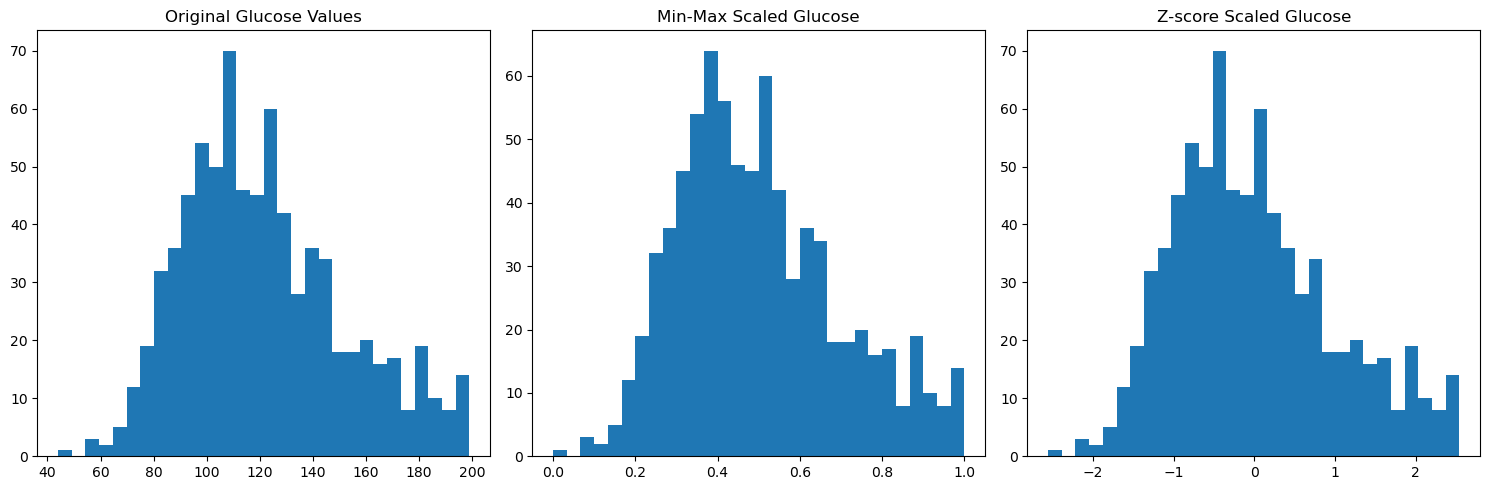

Standardized dataset saved successfully.


In [18]:
# Import required scalers
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Data standardization for selected columns
selected_columns = ['Glucose', 'BMI']
print("Applying standardization to columns:", selected_columns)

# Apply different scaling methods
minmax_scaler = MinMaxScaler()
minmax_scaled = minmax_scaler.fit_transform(diabetes_integrated[selected_columns])
minmax_df = pd.DataFrame(minmax_scaled, columns=[f"{col}_minmax" for col in selected_columns])

standard_scaler = StandardScaler()
zscore_scaled = standard_scaler.fit_transform(diabetes_integrated[selected_columns])
zscore_df = pd.DataFrame(zscore_scaled, columns=[f"{col}_zscore" for col in selected_columns])

def decimal_scaling(series):
    max_digits = len(str(int(abs(series).max())))
    return series / (10 ** max_digits)

decimal_scaled = diabetes_integrated[selected_columns].apply(decimal_scaling)
decimal_df = pd.DataFrame(decimal_scaled, columns=[f"{col}_decimal" for col in selected_columns])

# Visualize distributions
plt.figure(figsize=(15, 5))

plt.subplot(131)
plt.hist(diabetes_integrated['Glucose'], bins=30)
plt.title('Original Glucose Values')

plt.subplot(132)
plt.hist(minmax_df['Glucose_minmax'], bins=30)
plt.title('Min-Max Scaled Glucose')

plt.subplot(133)
plt.hist(zscore_df['Glucose_zscore'], bins=30)
plt.title('Z-score Scaled Glucose')

plt.tight_layout()
plt.show()

# Save standardized dataset
standardized_df = pd.concat([diabetes_integrated, minmax_df, zscore_df, decimal_df], axis=1)
standardized_df.to_csv('content/diabetes_standardized.csv', index=False)
print("Standardized dataset saved successfully.")